## Assignment

1. Apply all the regression and classification techniques learned on healthcare dataset

## Regression Task

In [148]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

### Creating the dataset for the regression task

In [149]:
np.random.seed(42)

n = 1000

age = np.random.randint(18, 80, n)
bmi = np.random.normal(27, 5, n)
blood_pressure = np.random.normal(120, 15, n)
cholesterol = np.random.normal(200, 30, n)
smoker = np.random.choice(['Yes', 'No'], n)

medical_cost = (
    age * 50 +
    bmi * 200 +
    blood_pressure * 15 +
    cholesterol * 10 +
    np.where(smoker=='Yes', 15000, 0) +
    np.random.normal(0, 5000, n)
)

reg_df = pd.DataFrame({
    'Age': age,
    'BMI': bmi,
    'BloodPressure': blood_pressure,
    'Cholesterol': cholesterol,
    'Smoker': smoker,
    'MedicalCost': medical_cost
})

# Add missing values
for col in ['BMI', 'BloodPressure', 'Cholesterol']:
    reg_df.loc[
        reg_df.sample(frac=0.1).index,
        col
    ] = np.nan

print(reg_df.head())

reg_df.to_csv("healthcare_regression.csv", index=False)

   Age        BMI  BloodPressure  Cholesterol Smoker   MedicalCost
0   56  33.861889     118.685426   221.039724    Yes  32548.035748
1   69  23.611070     122.290768   202.009454     No  14280.363927
2   46  32.767659     128.822999   221.671638     No  14752.649226
3   32        NaN     127.630024   173.164019    Yes  22006.643130
4   60        NaN            NaN          NaN     No  17851.173488


In [150]:
print(reg_df.info())

print(reg_df.describe())

print(reg_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1000 non-null   int64  
 1   BMI            900 non-null    float64
 2   BloodPressure  900 non-null    float64
 3   Cholesterol    900 non-null    float64
 4   Smoker         1000 non-null   object 
 5   MedicalCost    1000 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 47.0+ KB
None
               Age         BMI  BloodPressure  Cholesterol   MedicalCost
count  1000.000000  900.000000     900.000000   900.000000   1000.000000
mean     49.857000   27.195511     120.470681   199.940492  19505.127082
std      18.114267    5.296262      15.202389    30.293372   8888.242247
min      18.000000    9.158974      76.477145   102.816868  -2946.097520
25%      35.000000   23.861018     110.124313   179.913810  12338.747034
50%      50.000000   27.303994     12

In [151]:
reg_df.isnull().sum()

,0
Age,0
BMI,100
BloodPressure,100
Cholesterol,100
Smoker,0
MedicalCost,0


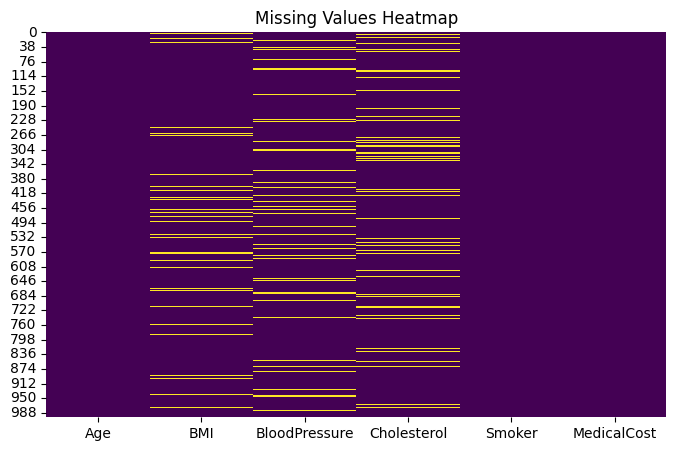

In [152]:
plt.figure(figsize=(8,5))

sns.heatmap(
    reg_df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

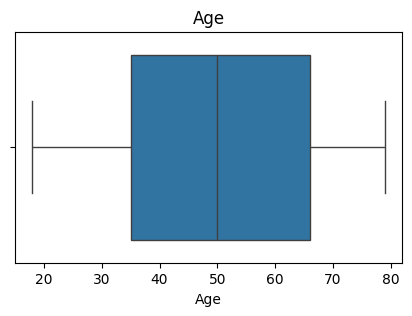

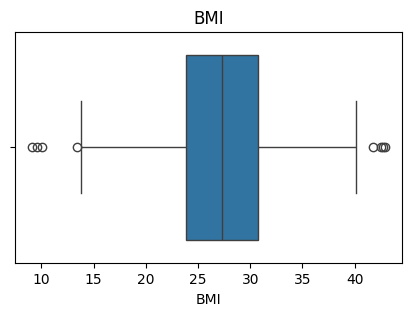

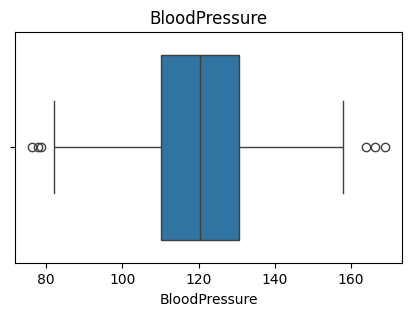

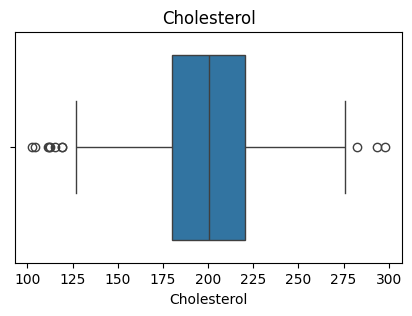

In [153]:
for col in ['Age','BMI','BloodPressure','Cholesterol']:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=reg_df[col])
    plt.title(col)
    plt.show()

In [154]:
for col in ['BMI','BloodPressure','Cholesterol']:
    reg_df[col].fillna(
        reg_df[col].median(),
        inplace=True
    )

/tmp/ipykernel_2281/1782989100.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reg_df[col].fillna(


In [155]:
reg_df['Smoker'] = LabelEncoder().fit_transform(reg_df['Smoker'])

X = reg_df.drop('MedicalCost', axis=1)
y = reg_df['MedicalCost']

numeric_cols = X.columns

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor

In [157]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "KNN": KNeighborsRegressor()
}

In [158]:
reg_results = []

for name, model in reg_models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    reg_results.append([
        name,
        mae,
        rmse,
        r2
    ])

reg_results_df = pd.DataFrame(
    reg_results,
    columns=['Model','MAE','RMSE','R2']
)

print(reg_results_df)

               Model          MAE         RMSE        R2
0  Linear Regression  3986.695522  5095.431056  0.696044
1      Decision Tree  6025.431306  7455.938822  0.349190
2      Random Forest  4204.140974  5335.280258  0.666755
3  Gradient Boosting  4111.008099  5180.002716  0.685870
4        Extra Trees  4188.299791  5406.904257  0.657747
5                KNN  4217.396615  5424.316951  0.655540


### Comparing the different regression models

In [159]:
reg_results_df.sort_values(
    by='R2',
    ascending=False,
    inplace=True
)

print(reg_results_df)

               Model          MAE         RMSE        R2
0  Linear Regression  3986.695522  5095.431056  0.696044
3  Gradient Boosting  4111.008099  5180.002716  0.685870
2      Random Forest  4204.140974  5335.280258  0.666755
4        Extra Trees  4188.299791  5406.904257  0.657747
5                KNN  4217.396615  5424.316951  0.655540
1      Decision Tree  6025.431306  7455.938822  0.349190


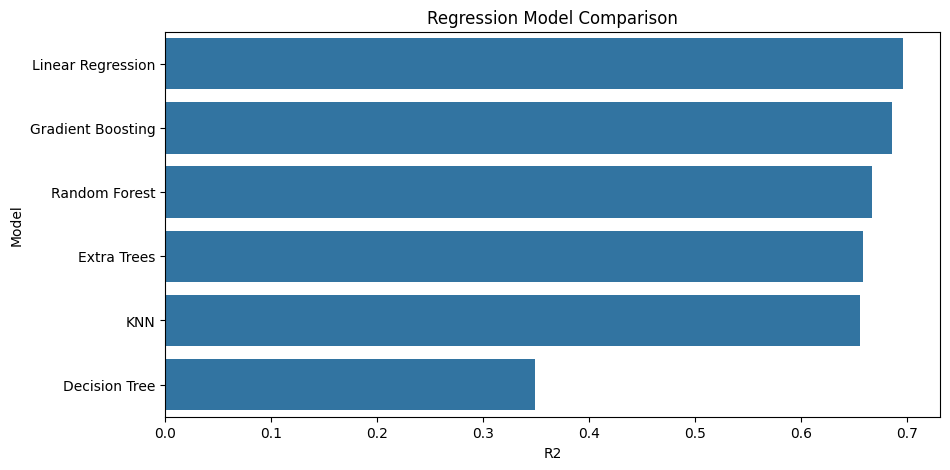

In [160]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='R2',
    y='Model',
    data=reg_results_df
)
plt.title("Regression Model Comparison")
plt.show()

# Classification Task

### Creating the data set

In [161]:
np.random.seed(42)

n = 1000

age = np.random.randint(18,80,n)
bmi = np.random.normal(28,5,n)
glucose = np.random.normal(120,30,n)
blood_pressure = np.random.normal(120,15,n)

diabetes = (
    (glucose > 130).astype(int) +
    (bmi > 30).astype(int) +
    (age > 50).astype(int)
)

diabetes = (diabetes >= 2).astype(int)

clf_df = pd.DataFrame({
    'Age': age,
    'BMI': bmi,
    'Glucose': glucose,
    'BloodPressure': blood_pressure,
    'Diabetes': diabetes
})

# Add missing values
for col in ['BMI','Glucose','BloodPressure']:
    clf_df.loc[
        clf_df.sample(frac=0.1).index,
        col
    ] = np.nan

print(clf_df.head())

clf_df.to_csv(
    "healthcare_classification.csv",
    index=False
)

   Age        BMI     Glucose  BloodPressure  Diabetes
0   56  34.861889  117.370852     130.519862         1
1   69  24.611070  124.581537     121.004727         0
2   46  33.767659  137.645998     130.835819         1
3   32        NaN  135.260047     106.582010         0
4   60        NaN   47.048593            NaN         0


## EDA

In [162]:
print(clf_df.info())

print(clf_df.describe())

print(clf_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1000 non-null   int64  
 1   BMI            900 non-null    float64
 2   Glucose        900 non-null    float64
 3   BloodPressure  900 non-null    float64
 4   Diabetes       1000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 39.2 KB
None
               Age         BMI     Glucose  BloodPressure     Diabetes
count  1000.000000  900.000000  900.000000     900.000000  1000.000000
mean     49.857000   28.246897  120.841447     119.950326     0.380000
std      18.114267    5.293834   30.737552      15.145707     0.485629
min      18.000000   10.609154   32.954290      71.408434     0.000000
25%      35.000000   24.841997   99.478343     109.956905     0.000000
50%      50.000000   28.318724  121.702101     120.206054     0.000000
75%      66.000000   31.844800  14

In [163]:
missing_percentage = (clf_df.isnull().sum()/len(clf_df))*100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
Age               0.0
BMI              10.0
Glucose          10.0
BloodPressure    10.0
Diabetes          0.0
dtype: float64


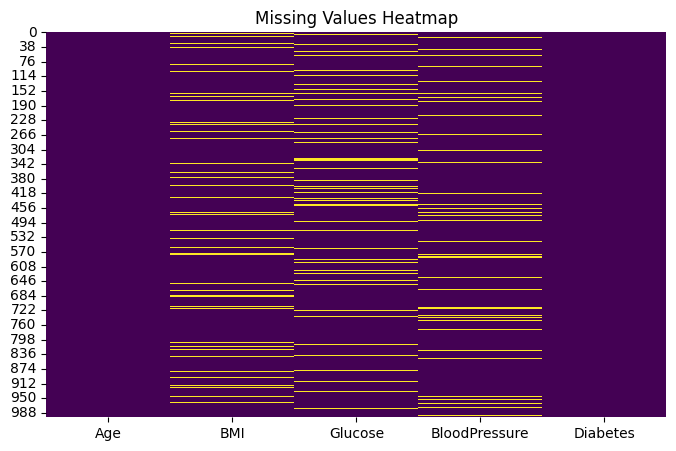

In [164]:
plt.figure(figsize=(8,5))

sns.heatmap(
    clf_df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

In [165]:
for col in ['BMI', 'Glucose', 'BloodPressure']:

    median_value = clf_df[col].median()

    clf_df[col].fillna(
        median_value,
        inplace=True
    )

/tmp/ipykernel_2281/1236928360.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clf_df[col].fillna(


In [166]:
print(clf_df.isnull().sum())

Age              0
BMI              0
Glucose          0
BloodPressure    0
Diabetes         0
dtype: int64


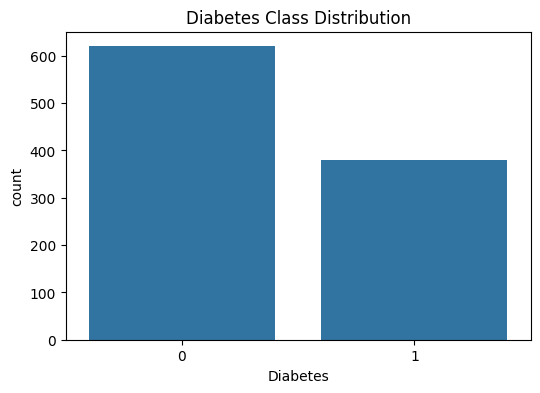

Diabetes
0    620
1    380
Name: count, dtype: int64


In [167]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Diabetes',
    data=clf_df
)

plt.title("Diabetes Class Distribution")
plt.show()
print(clf_df['Diabetes'].value_counts())

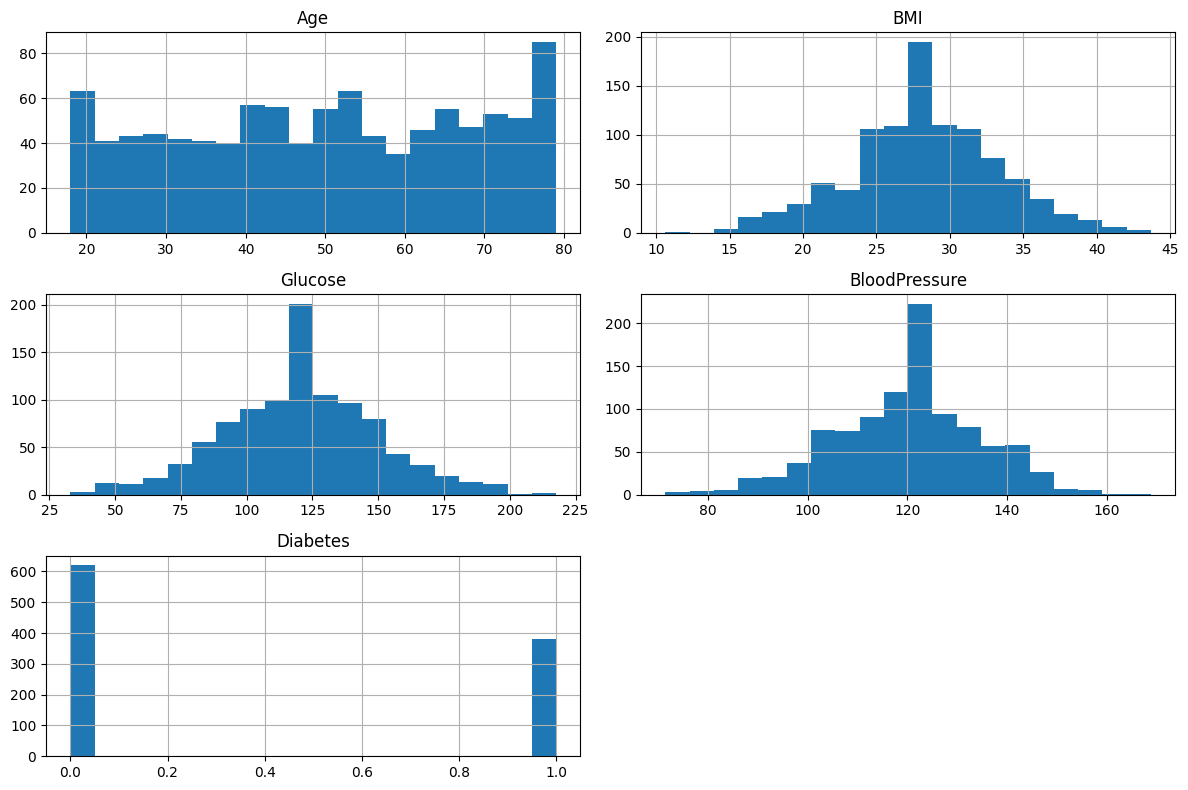

In [168]:
clf_df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

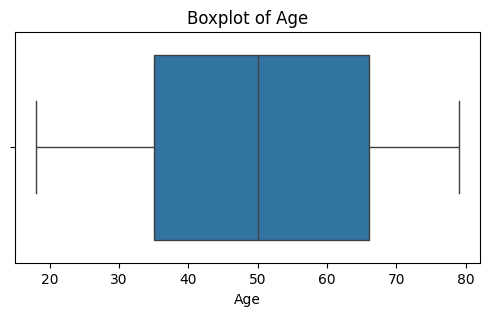

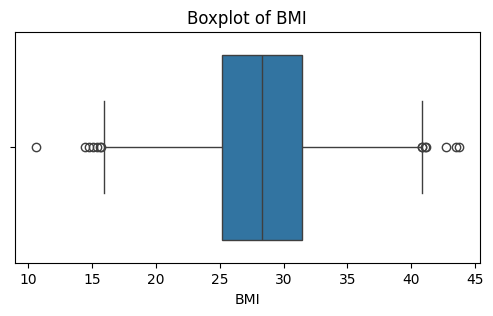

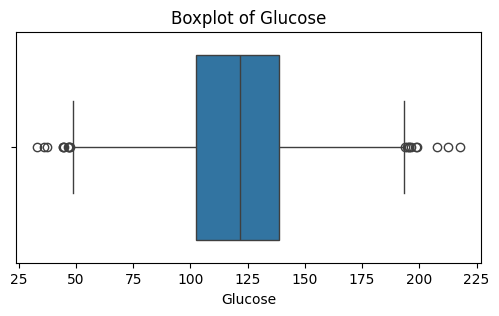

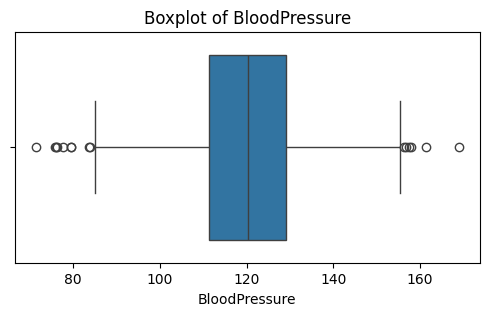

In [169]:
numerical_cols = [
    'Age',
    'BMI',
    'Glucose',
    'BloodPressure'
]

for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=clf_df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

### correlation matrix

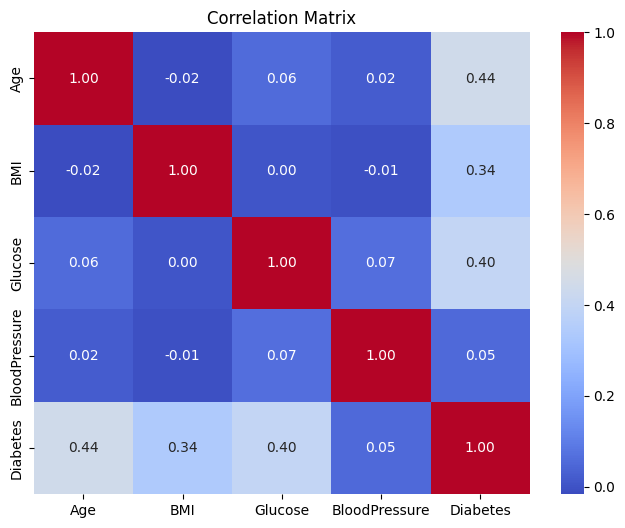

In [170]:
plt.figure(figsize=(8,6))

sns.heatmap(
    clf_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [171]:
print("Shape:", clf_df.shape)

print("\nMissing Values:")
print(clf_df.isnull().sum())

print("\nClass Distribution:")
print(clf_df['Diabetes'].value_counts())

print("\nCorrelation Matrix:")
print(clf_df.corr())

Shape: (1000, 5)

Missing Values:
Age              0
BMI              0
Glucose          0
BloodPressure    0
Diabetes         0
dtype: int64

Class Distribution:
Diabetes
0    620
1    380
Name: count, dtype: int64

Correlation Matrix:
                    Age       BMI   Glucose  BloodPressure  Diabetes
Age            1.000000 -0.016543  0.058158       0.020511  0.441435
BMI           -0.016543  1.000000  0.003406      -0.005972  0.336955
Glucose        0.058158  0.003406  1.000000       0.065609  0.398044
BloodPressure  0.020511 -0.005972  0.065609       1.000000  0.051181
Diabetes       0.441435  0.336955  0.398044       0.051181  1.000000


### Data processing for classification

In [172]:
X = clf_df.drop('Diabetes', axis=1)
y = clf_df['Diabetes']

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [173]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [174]:
clf_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [175]:
clf_results = []

for name, model in clf_models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    clf_results.append([
        name,
        acc,
        precision,
        recall,
        f1
    ])

clf_results_df = pd.DataFrame(
    clf_results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print(clf_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.865   0.821918  0.810811  0.816327
1        Decision Tree     0.965   0.935065  0.972973  0.953642
2        Random Forest     0.970   0.972222  0.945946  0.958904
3    Gradient Boosting     0.965   0.958904  0.945946  0.952381
4                  KNN     0.915   0.913043  0.851351  0.881119
5          Naive Bayes     0.845   0.830769  0.729730  0.776978


In [176]:
clf_results_df.sort_values(
    by='Accuracy',
    ascending=False,
    inplace=True
)

print(clf_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest     0.970   0.972222  0.945946  0.958904
1        Decision Tree     0.965   0.935065  0.972973  0.953642
3    Gradient Boosting     0.965   0.958904  0.945946  0.952381
4                  KNN     0.915   0.913043  0.851351  0.881119
0  Logistic Regression     0.865   0.821918  0.810811  0.816327
5          Naive Bayes     0.845   0.830769  0.729730  0.776978


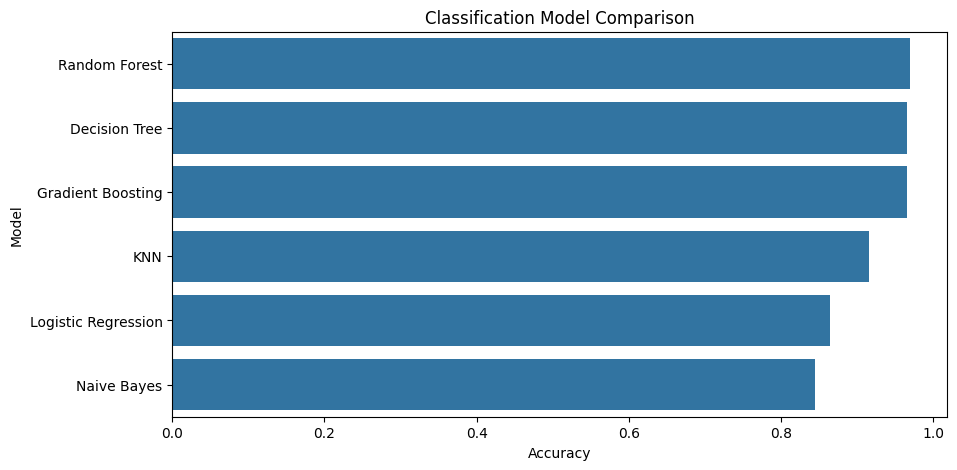

In [177]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=clf_results_df
)

plt.title("Classification Model Comparison")
plt.show()